In [5]:
#
# 설치
#

!pip install ultralytics roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 110.0 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18


In [6]:
#
# google drive 연결
#

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
#
# 데이터셋 다운로드
#

from google.colab import userdata
from roboflow import Roboflow

api_key = userdata.get('ROBOFLOW_API_KEY')
rf = Roboflow(api_key=api_key)
project = rf.workspace("s-workspace-pv7pr").project("findeye_osp")
version = project.version(1)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to FINDEYE_OSP-1 in yolov11:: 100%|██████████| 2043/2043 [00:00<00:00, 3379.14it/s]


In [8]:
#
# YOLO 학습
#

from ultralytics import YOLO

model = YOLO("yolo11n.pt")
model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=50,
    imgsz=640,
    project="/content/drive/MyDrive/FindEye",  # Google Drive에 저장
    name="weights"
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.68 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/FINDEYE_OSP-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c1d66246c60>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

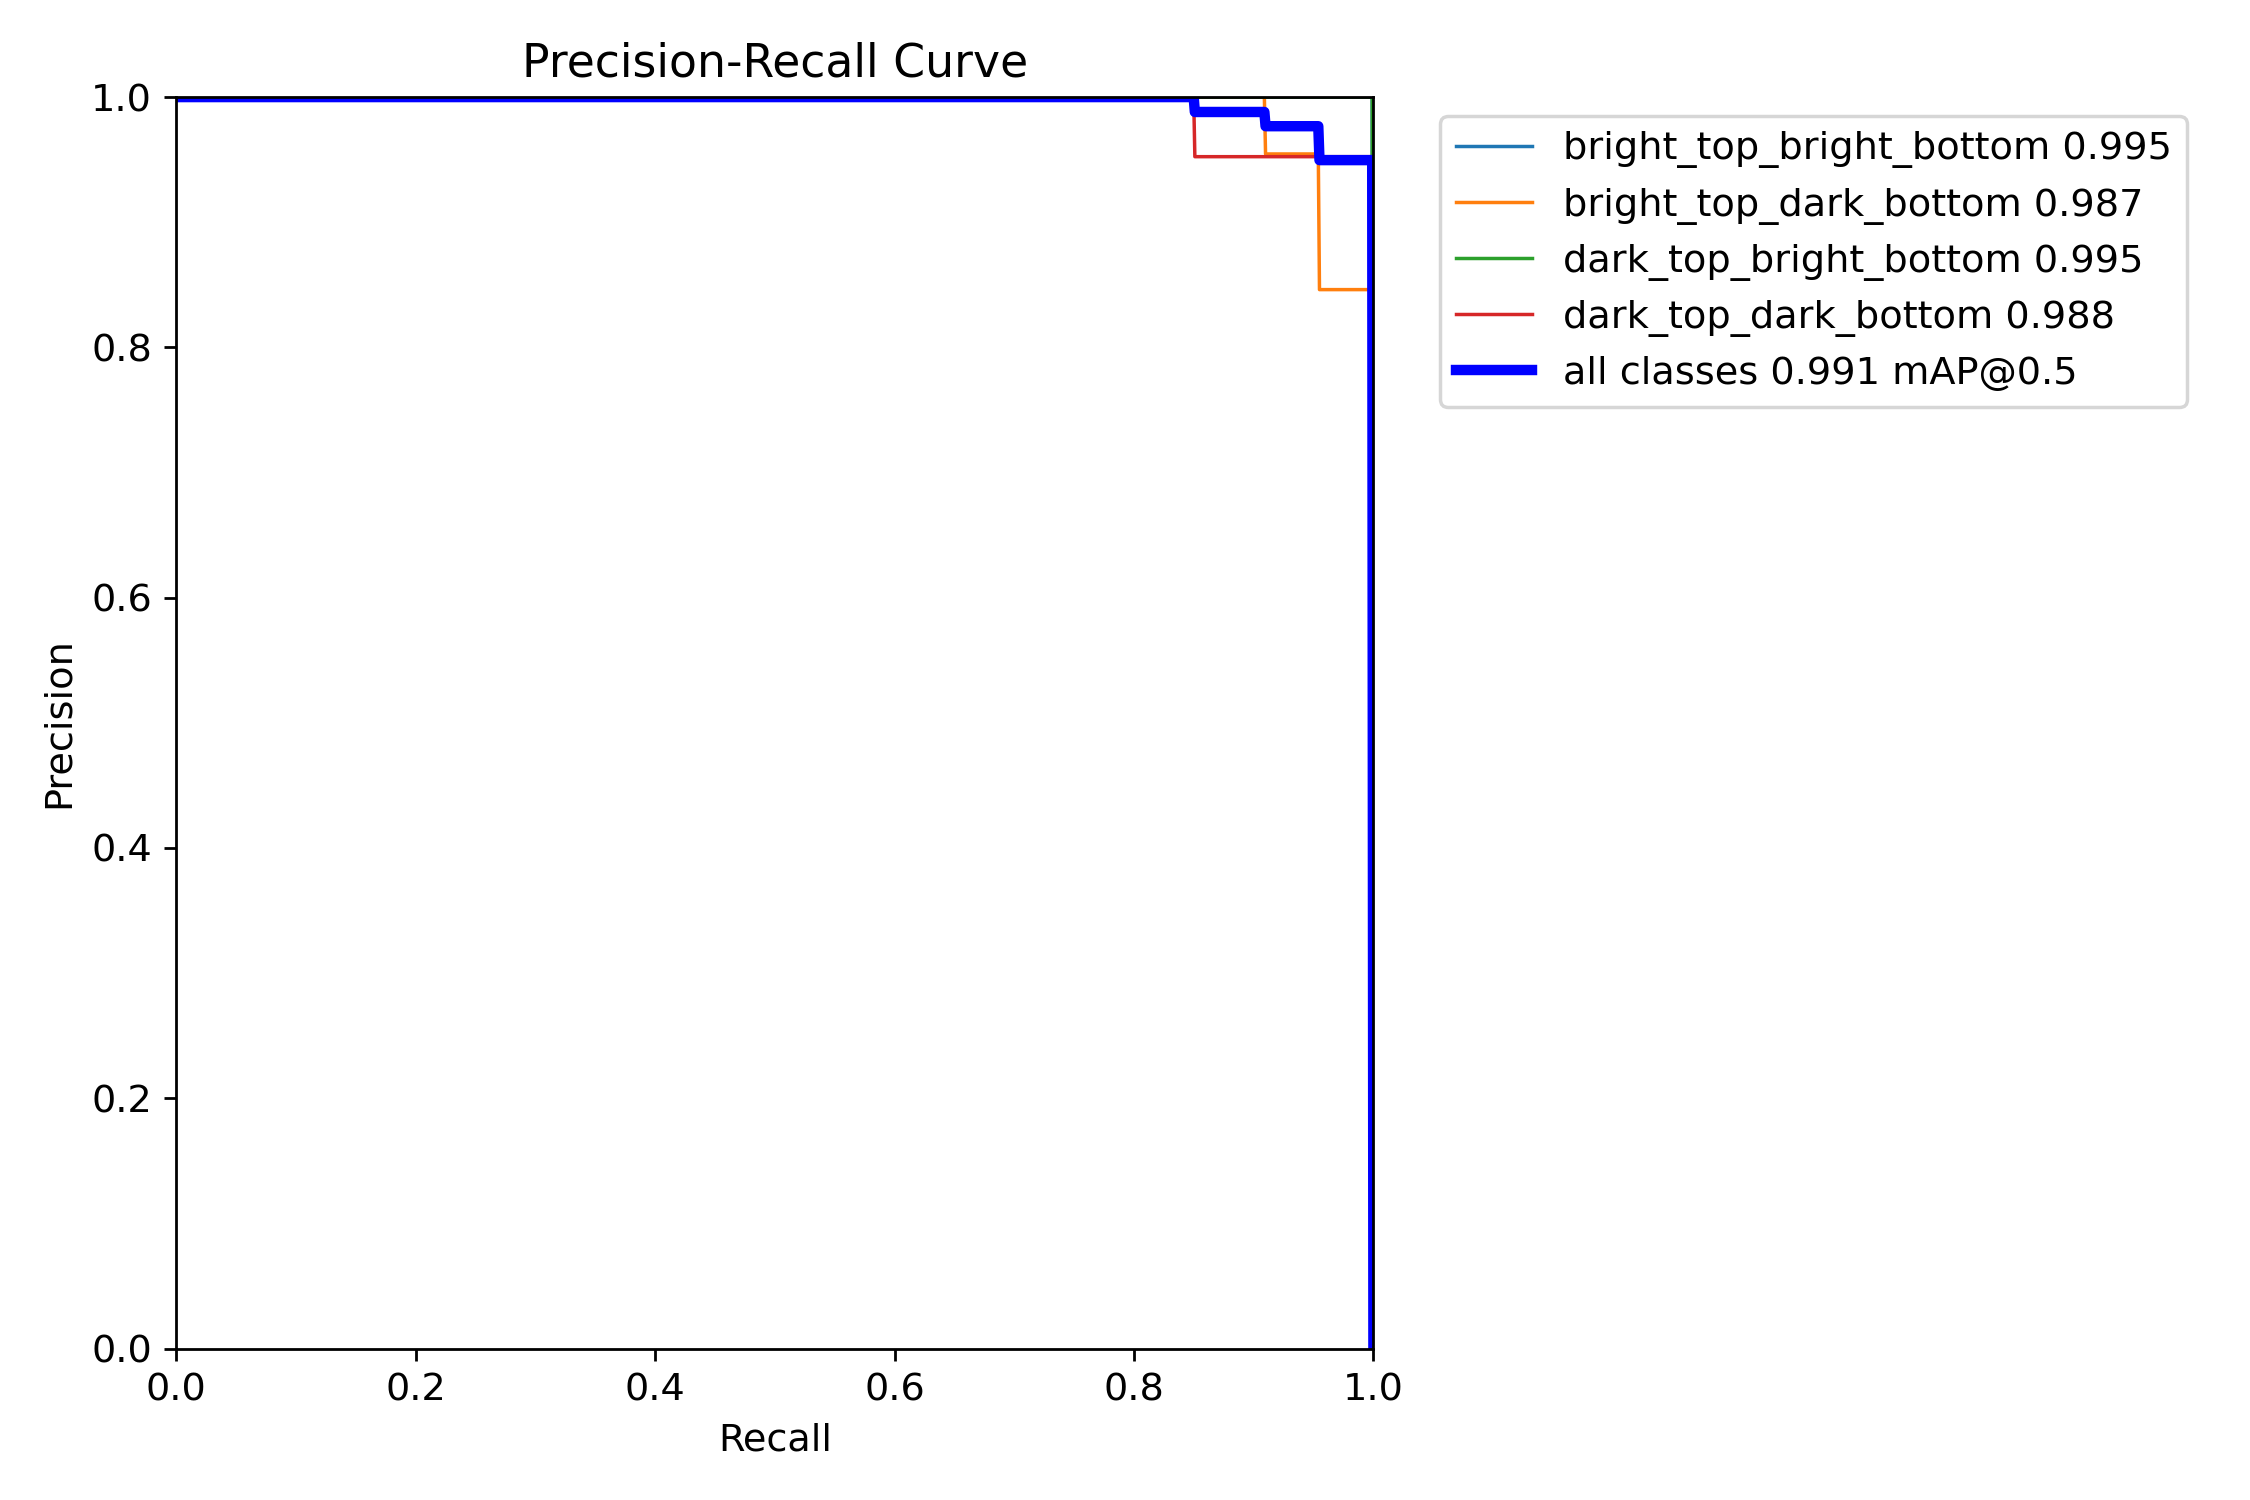

In [9]:
#
# 학습결과확인
#

import glob
results = glob.glob("/content/drive/MyDrive/FindEye/weights/*.png")
from IPython.display import Image
Image(results[0])

**학습률(Learning Rate) 실험**

In [13]:
from ultralytics import YOLO

# 기본 모델을 불러와서 학습률을 0.005로 변경하여 학습
model_lr = YOLO('yolo11s.pt')
results_lr = model_lr.train(
    data=f"{dataset.location}/data.yaml",
    epochs=50,
    imgsz=640,
    lr0=0.005,                  # ★ 조작 변인: 학습률 변경
    project='FindEye_Experiments',
    name='lr_0005_exp'
)

Ultralytics 8.4.68 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/FINDEYE_OSP-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=lr_0005_exp-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, p

=== 1. 학습률(0.005) 실험: 학습 곡선 ===


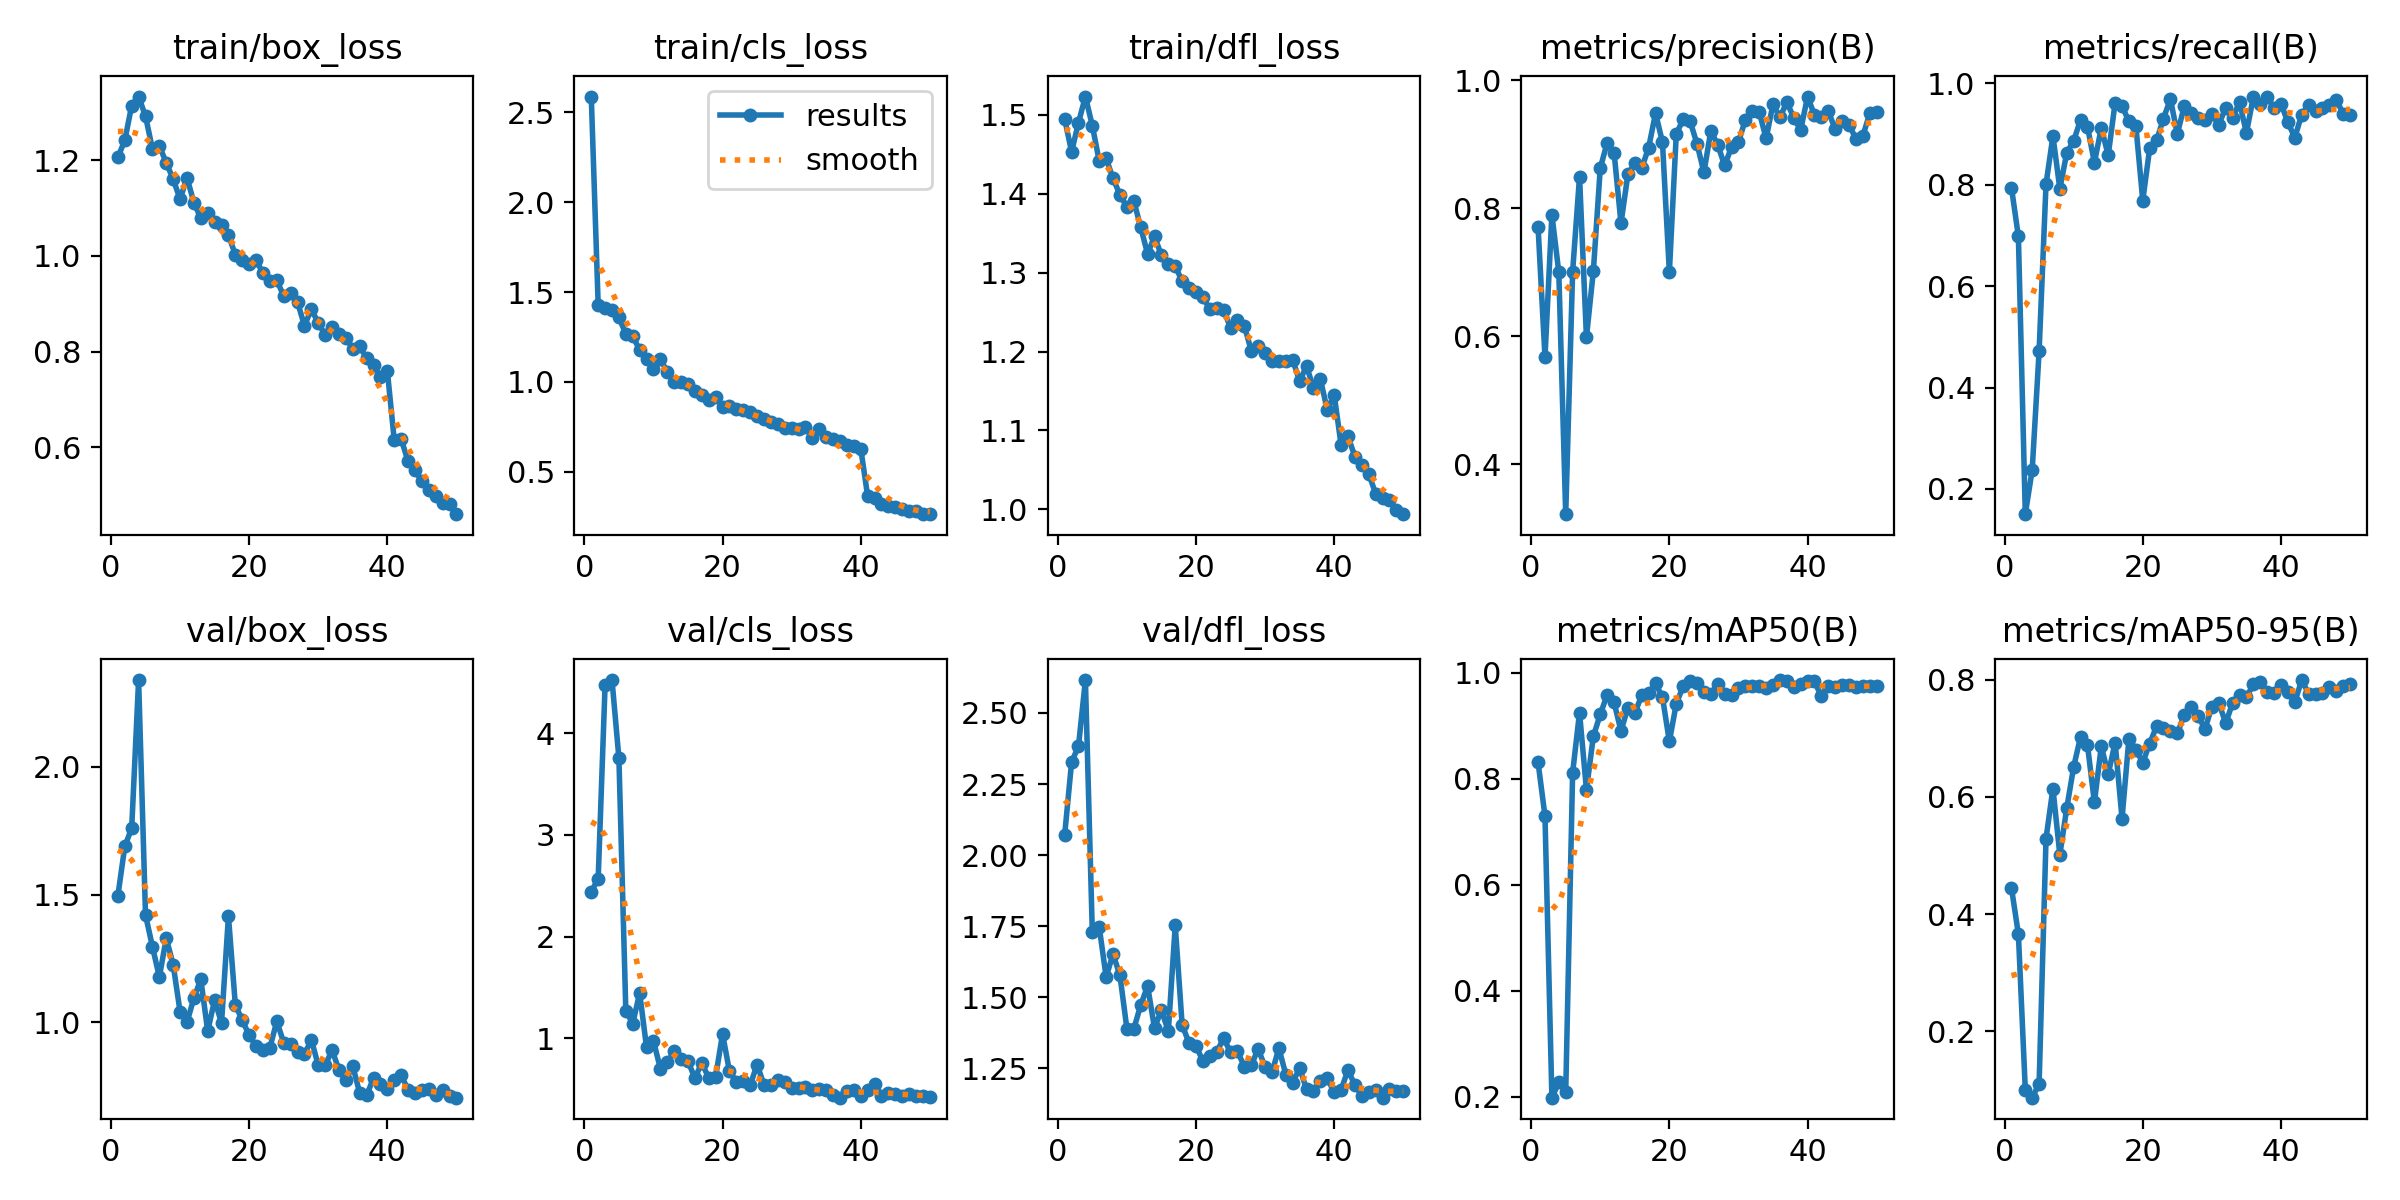


=== 1. 학습률(0.005) 실험: 오분류표 ===


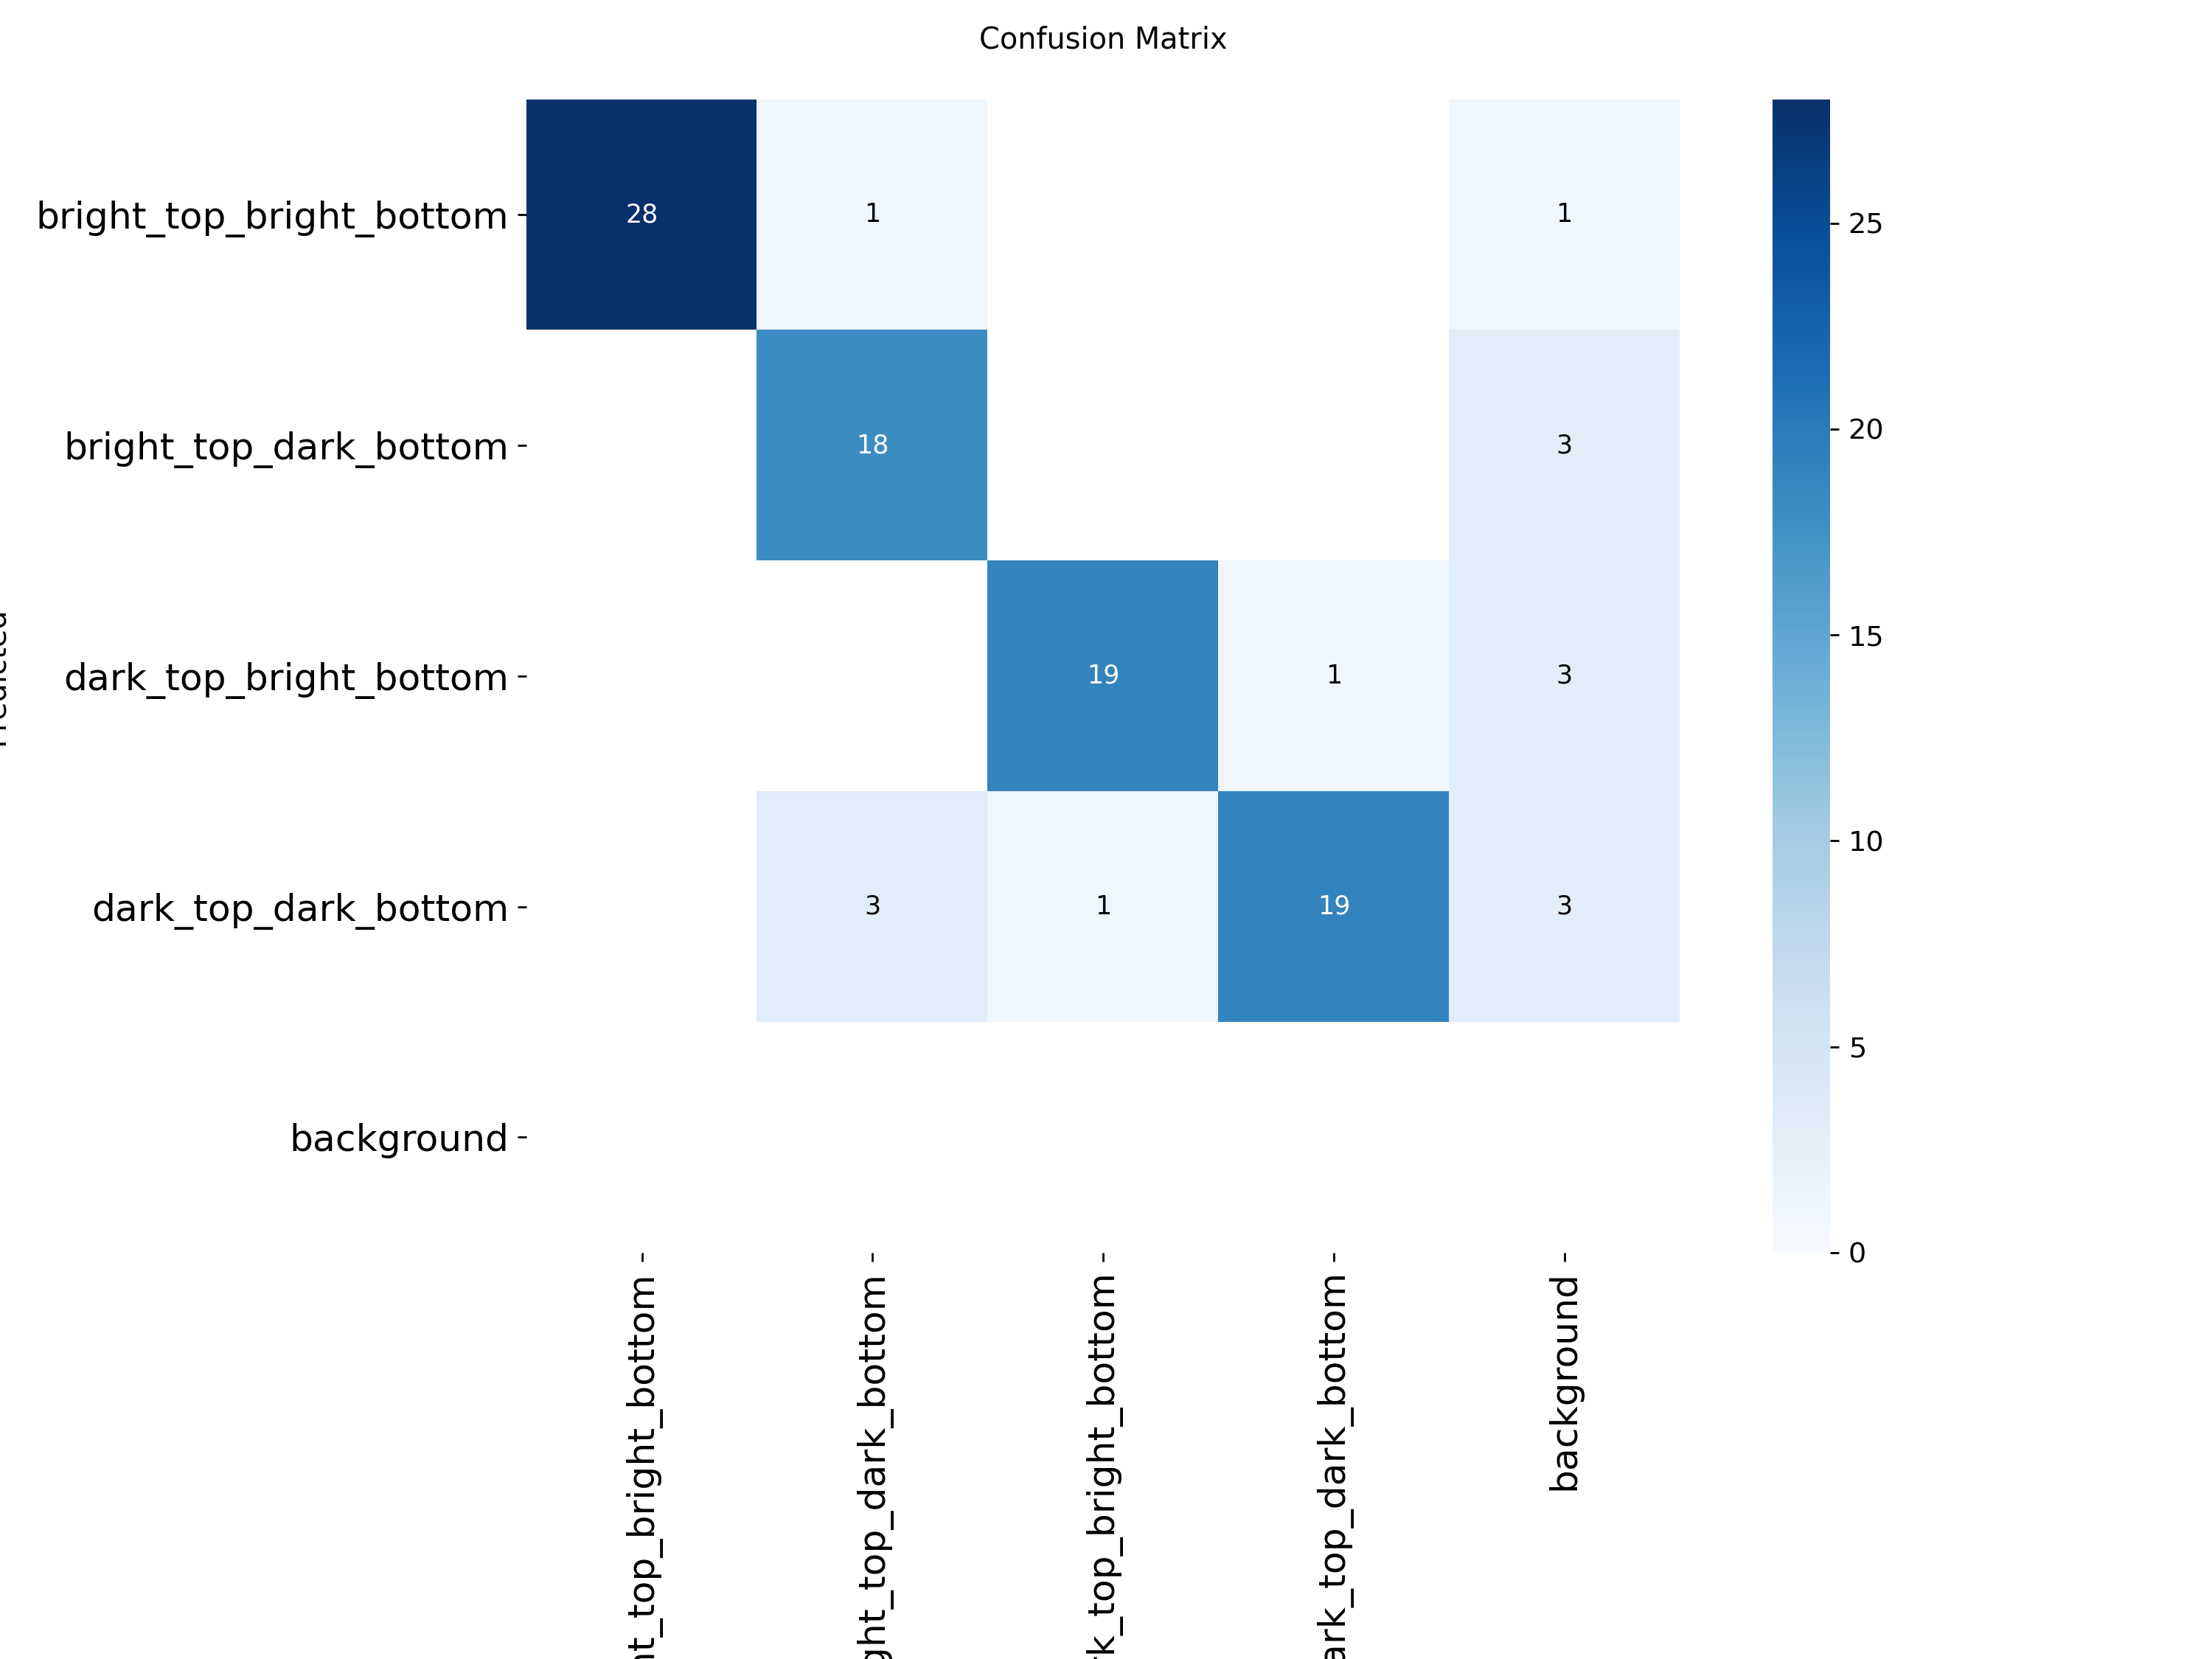

In [20]:
from IPython.display import Image, display

print("=== 1. 학습률(0.005) 실험: 학습 곡선 ===")
display(Image('/content/runs/detect/FindEye_Experiments/lr_0005_exp-3/results.png'))

print("\n=== 1. 학습률(0.005) 실험: 오분류표 ===")
display(Image('/content/runs/detect/FindEye_Experiments/lr_0005_exp-3/confusion_matrix.png'))

**밝기 증강(Augmentation) 실험**

In [21]:
from ultralytics import YOLO

model_aug = YOLO('yolo11s.pt')

# 두 번째 실험: 밝기 증강(Augmentation)
results_aug = model_aug.train(
    data=f"{dataset.location}/data.yaml",
    epochs=50,
    imgsz=640,
    hsv_v=0.2,                  # ★ 조작 변인: 밝기 변형 파라미터 조절
    project='FindEye_Experiments',
    name='aug_brightness_exp'
)

Ultralytics 8.4.68 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/FINDEYE_OSP-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.2, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=aug_brightness_exp, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tru

=== 2. 밝기 증강 실험: 학습 곡선 (/content/runs/detect/FindEye_Experiments/aug_brightness_exp) ===


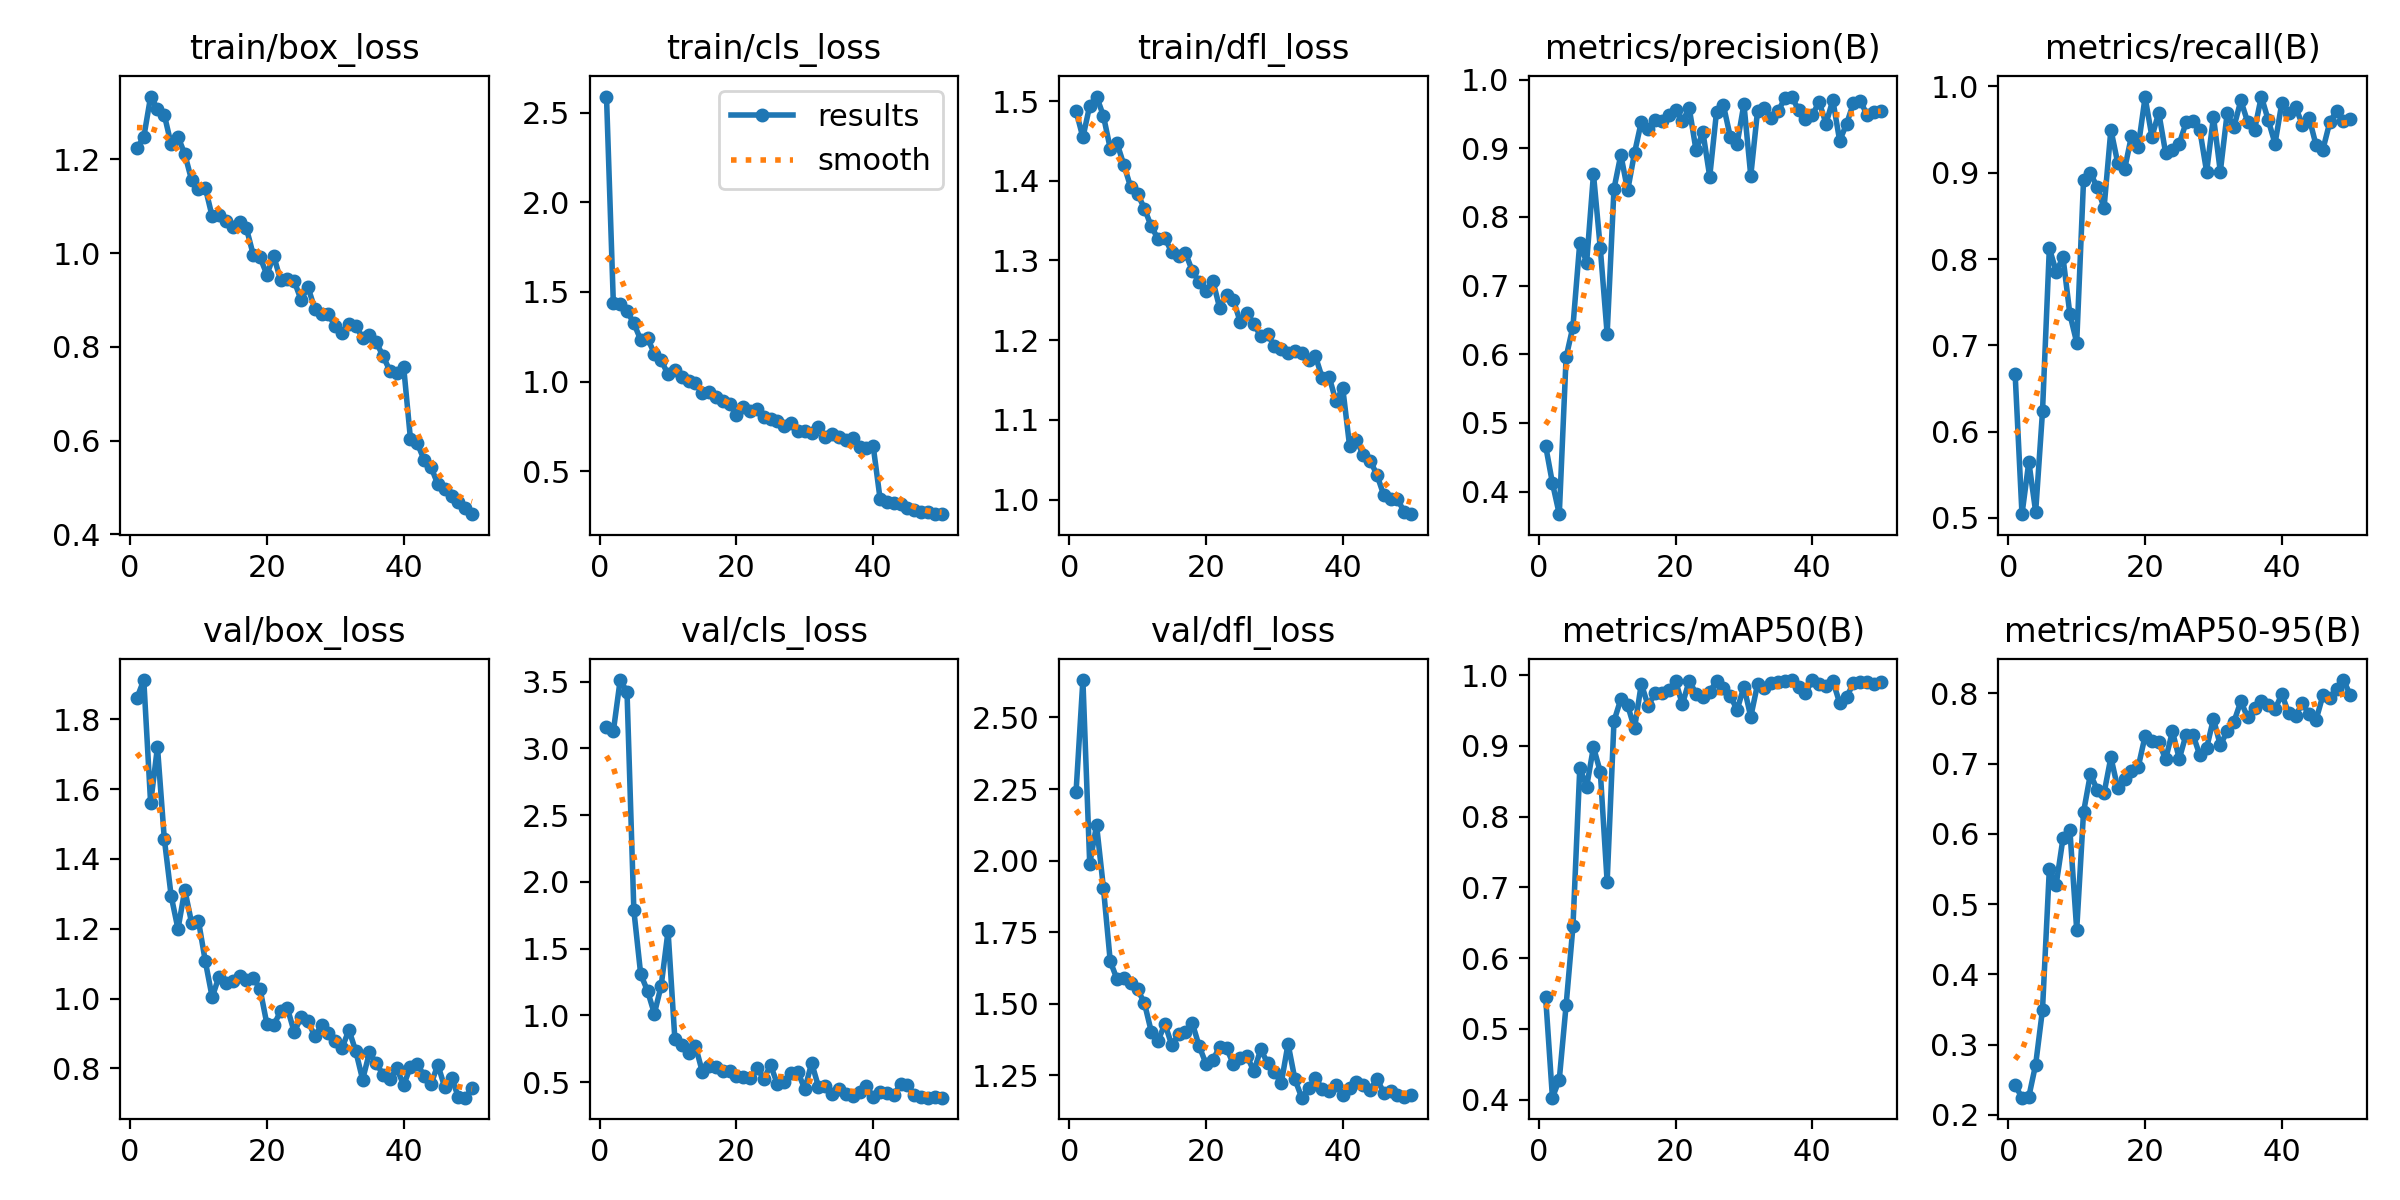


=== 2. 밝기 증강 실험: 오분류표 ===


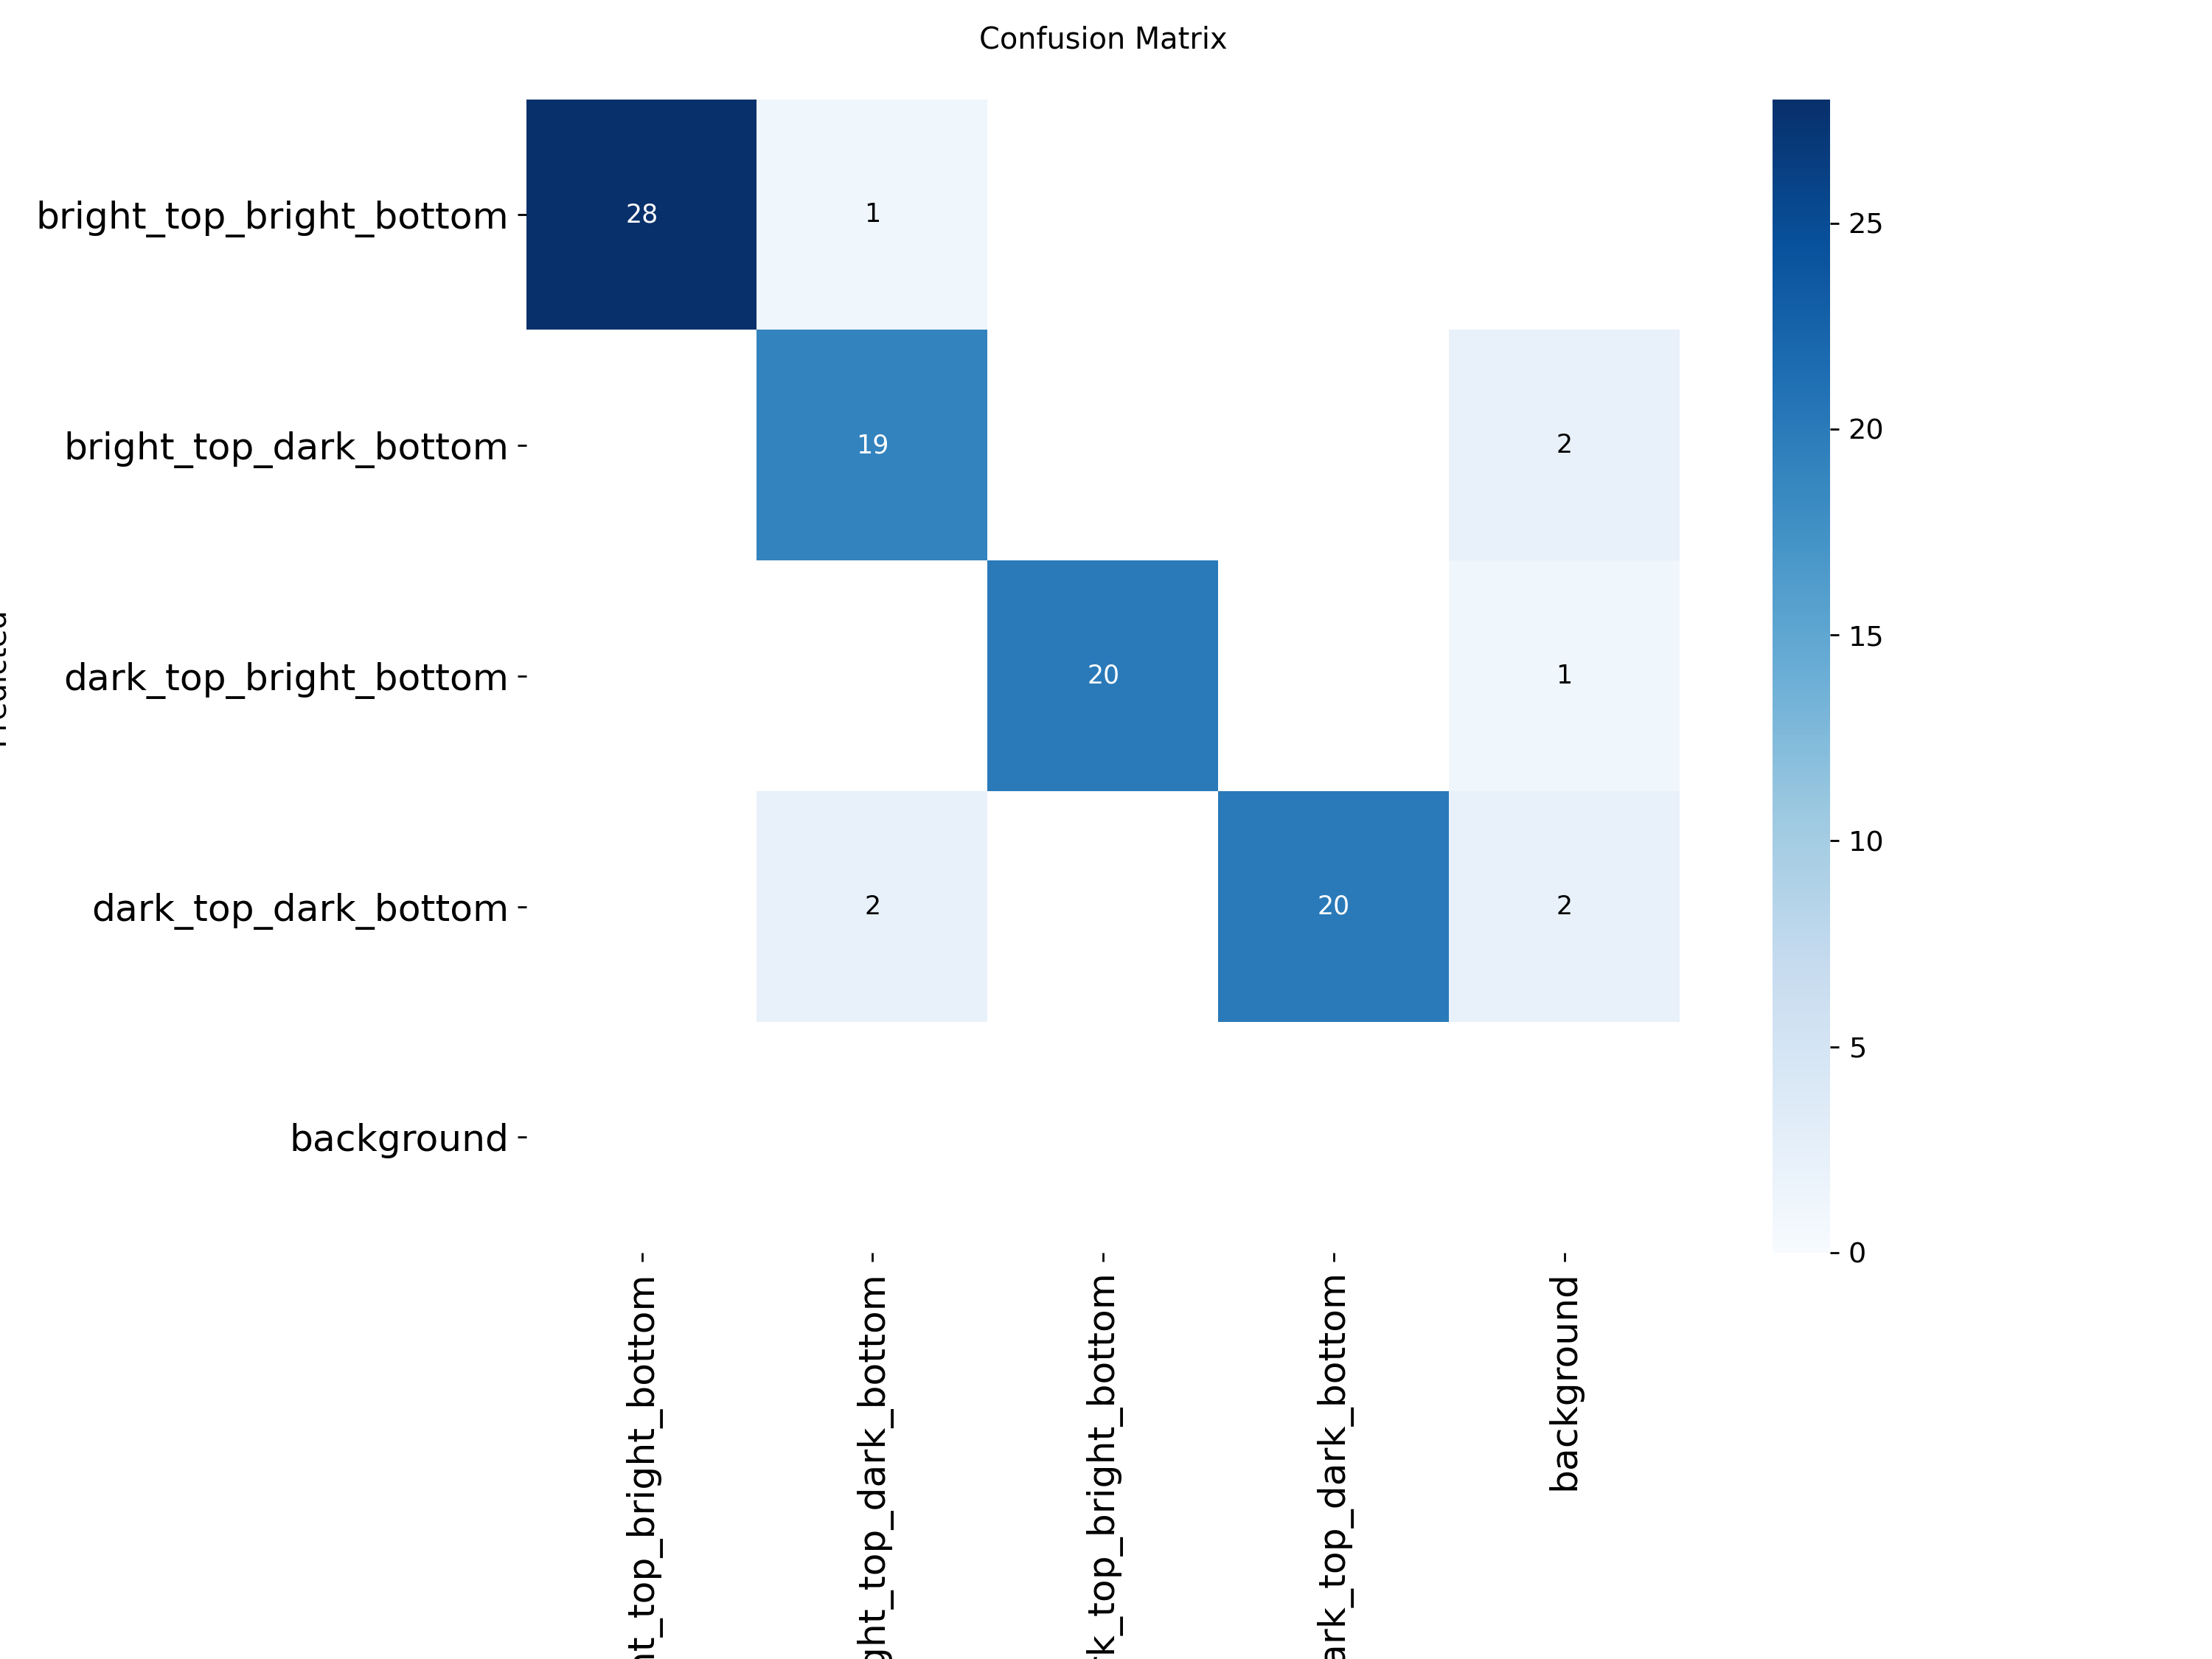

In [22]:
import glob
from IPython.display import Image, display

# 두 번째 실험 폴더를 자동으로 찾습니다.
aug_folders = sorted(glob.glob('/content/runs/detect/FindEye_Experiments/aug_brightness_exp*'))

if aug_folders:
    latest_folder = aug_folders[-1]
    print(f"=== 2. 밝기 증강 실험: 학습 곡선 ({latest_folder}) ===")
    display(Image(f'{latest_folder}/results.png'))

    print("\n=== 2. 밝기 증강 실험: 오분류표 ===")
    display(Image(f'{latest_folder}/confusion_matrix.png'))
else:
    print("두 번째 실험 폴더를 아직 찾을 수 없습니다. (학습 진행 중일 수 있습니다)")


             📊 [Final Epoch Metrics Summary]             


,Precision,Recall,mAP50,mAP50-95
Experiment,,,,
Baseline (Default),0.94736,0.97443,0.98879,0.80956
LR Exp (0.005),0.87418,0.89746,0.94486,0.65330
Aug Exp (0.2),0.95386,0.96239,0.98995,0.79788


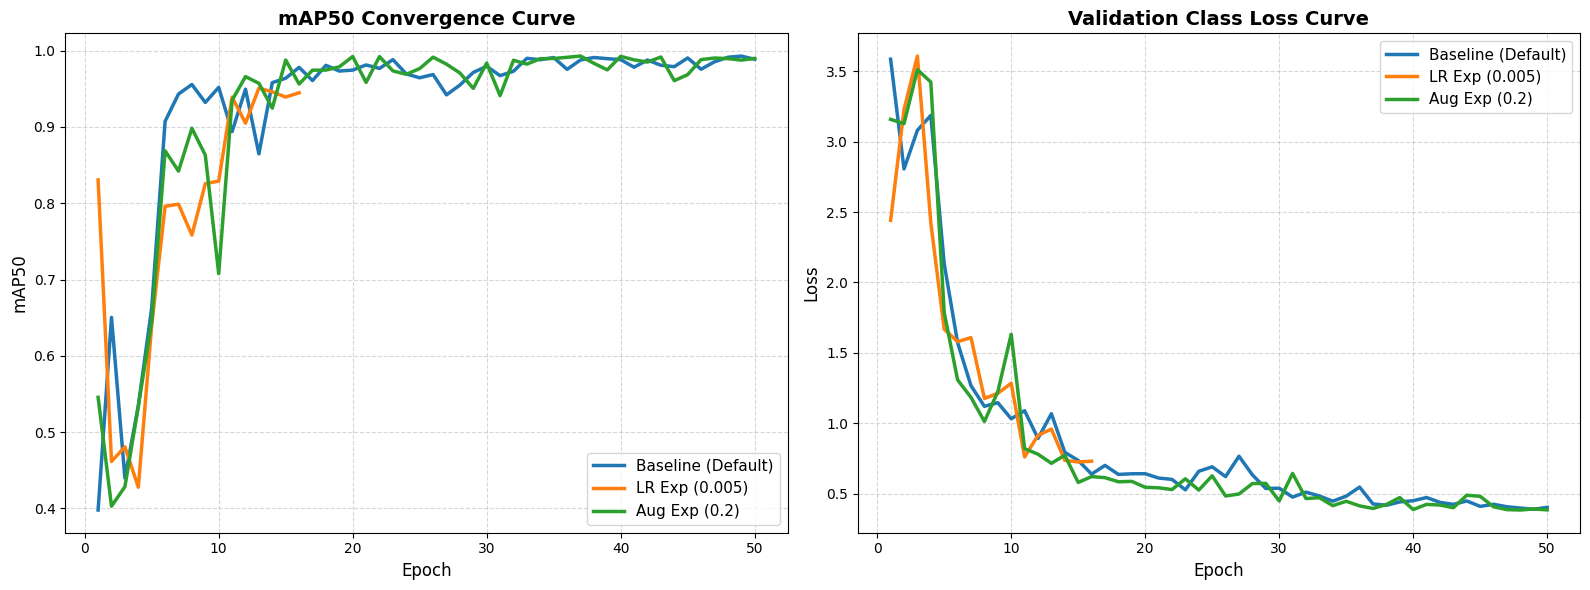

In [29]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
from IPython.display import display

# 1. 비교할 모든 실험의 results.csv 경로 지정
paths = {
    "Baseline (Default)": "/content/drive/MyDrive/FindEye/weights/results.csv",
    "LR Exp (0.005)": "/content/runs/detect/FindEye_Experiments/lr_0005_exp*/results.csv",
    "Aug Exp (0.2)": "/content/runs/detect/FindEye_Experiments/aug_brightness_exp*/results.csv"
}

dfs = {}
summary_list = []

# 2. 데이터 로드 및 최종 지표 추출
for exp_name, search_path in paths.items():
    files = sorted(glob.glob(search_path))
    if not files:
        print(f"⚠️ [{exp_name}] File not found. Check the path.")
        continue

    # 가장 최신 csv 파일 로드
    latest_file = files[-1]
    df = pd.read_csv(latest_file)
    df.columns = df.columns.str.strip() # 열 이름 공백 제거
    dfs[exp_name] = df

    # 마지막 에폭(50에폭)의 핵심 지표 저장
    final_epoch = df.iloc[-1]
    summary_list.append({
        "Experiment": exp_name,
        "Precision": final_epoch["metrics/precision(B)"],
        "Recall": final_epoch["metrics/recall(B)"],
        "mAP50": final_epoch["metrics/mAP50(B)"],
        "mAP50-95": final_epoch["metrics/mAP50-95(B)"]
    })

# 3. 하나의 표로 깔끔하게 비교 출력
if summary_list:
    print("\n" + "="*60)
    print("             📊 [Final Epoch Metrics Summary]             ")
    print("="*60)
    summary_df = pd.DataFrame(summary_list).set_index("Experiment")
    display(summary_df)
    print("="*60 + "\n")

# 4. 학습 곡선 통합 비교 시각화 (하나의 그래프에 겹쳐 그리기)
if dfs:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # 왼쪽 그래프: mAP50 정확도 수렴 추이 비교
    for exp_name, df in dfs.items():
        if "metrics/mAP50(B)" in df.columns:
            axes[0].plot(df["epoch"], df["metrics/mAP50(B)"], label=exp_name, linewidth=2.5)
    axes[0].set_title("mAP50 Convergence Curve", fontsize=14, fontweight='bold')
    axes[0].set_xlabel("Epoch", fontsize=12)
    axes[0].set_ylabel("mAP50", fontsize=12)
    axes[0].legend(fontsize=11)
    axes[0].grid(True, linestyle="--", alpha=0.5)

    # 오른쪽 그래프: 검증 클래스 손실(Validation Class Loss) 추이 비교
    for exp_name, df in dfs.items():
        if "val/cls_loss" in df.columns:
            axes[1].plot(df["epoch"], df["val/cls_loss"], label=exp_name, linewidth=2.5)
    axes[1].set_title("Validation Class Loss Curve", fontsize=14, fontweight='bold')
    axes[1].set_xlabel("Epoch", fontsize=12)
    axes[1].set_ylabel("Loss", fontsize=12)
    axes[1].legend(fontsize=11)
    axes[1].grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()